In [1]:
import pandas as pd

data = []
with open('data_1600_accel_watch.txt') as f:
    for line in f:
        line = line.replace(';','').strip()   # remove semicolon
        parts = line.split(',')
        user = int(parts[0])
        activity = parts[1]
        x = float(parts[2])
        y = float(parts[3])
        z = float(parts[4])
        data.append([user, activity, x, y, z])

df = pd.DataFrame(data, columns=['user','activity','x','y','z'])
df.head()

,user,activity,x,y,z
0,1600,A,7.091625,-0.591667,8.195502
1,1600,A,4.972757,-0.158317,6.696732
2,1600,A,3.253720,-0.191835,6.107758
3,1600,A,2.801216,-0.155922,5.997625
4,1600,A,3.770868,-1.051354,7.731027


In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['activity'] = le.fit_transform(df['activity'])

df[['x','y','z']] = df[['x','y','z']].apply(lambda col: (col - col.mean())/col.std())

In [3]:
import numpy as np

def create_windows(df, window=16, overlap=0.5):
    step = int(window * (1-overlap))
    segments = []
    labels = []
    
    for i in range(0, len(df)-window, step):
        x = df['x'].values[i:i+window]
        y = df['y'].values[i:i+window]
        z = df['z'].values[i:i+window]
        activity = df['activity'].values[i:i+window]
        
        segments.append([x, y, z])
        labels.append(np.bincount(activity).argmax())

    return np.asarray(segments), np.asarray(labels)

X, y = create_windows(df, window=16, overlap=0.5)
X = X.transpose(0,2,1)     # shape → (samples, 16, 3)
X.shape, y.shape

((1798, 16, 3), (1798,))

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split


num_classes = len(np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

num_classes = len(np.unique(y))

model = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(16,3)),
    MaxPooling1D(2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(X, y, epochs=10, batch_size=1)

Epoch 1/10


C:\Users\Manit\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1798/1798 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7992 - loss: 0.5475
Epoch 2/10
1798/1798 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9055 - loss: 0.2568
Epoch 3/10
1798/1798 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9338 - loss: 0.1879
Epoch 4/10
1798/1798 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9505 - loss: 0.1456
Epoch 5/10
1798/1798 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9588 - loss: 0.1184
Epoch 6/10
1798/1798 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9577 - loss: 0.1155
Epoch 7/10
1798/1798 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9650 - loss: 0.0923
Epoch 8/10
1798/1798 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9694 - loss: 0.0836
Epoch 9/10
1798/1798 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9755 - loss: 0.0695
Epoch 10/10
1798/1798 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9800 - loss: 0.0578


In [8]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc*100:.2f}%")

Test Accuracy: 98.06%


In [9]:
y_pred = np.argmax(model.predict(X_test), axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [10]:
activity_labels = ['walking','jogging','upstairs','downstairs','sitting','standing']

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

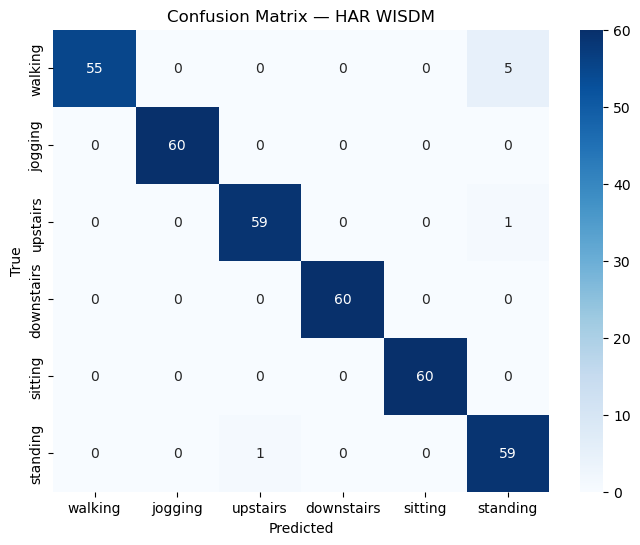

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=activity_labels,
            yticklabels=activity_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — HAR WISDM")
plt.show()

In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=activity_labels))

              precision    recall  f1-score   support

     walking       1.00      0.92      0.96        60
     jogging       1.00      1.00      1.00        60
    upstairs       0.98      0.98      0.98        60
  downstairs       1.00      1.00      1.00        60
     sitting       1.00      1.00      1.00        60
    standing       0.91      0.98      0.94        60

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360

